In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score
import xgboost as xgb
import pickle


In [ ]:
df = pd.read_csv('/content/monthly_features-2.csv')

In [ ]:
df.head()

,Year,Month,Total_Sales,Avg_Sales,Order_count,Customer_count,Lag_1,Lag_2,Lag_3,Rolling_3,Mom_1,Mom_3,Growth_rate,Quarter,Month_Sin,Month_Cos,Is_Holiday_Month,Is_Quarter_END
0,2015,4,27906.8550,214.668115,63,61,55205.7970,4519.8920,14205.707,24643.798667,-27298.9420,13701.1480,-49.449412,2,8.660254e-01,-0.500000,0,0
1,2015,5,23644.3030,195.407463,68,66,27906.8550,55205.7970,4519.892,29210.848000,-4262.5520,19124.4110,-15.274211,2,5.000000e-01,-0.866025,0,0
2,2015,6,34322.9356,262.007142,64,61,23644.3030,27906.8550,55205.797,35585.651667,10678.6326,-20882.8614,45.163660,2,1.224647e-16,-1.000000,0,1
3,2015,7,33781.5430,237.898190,64,64,34322.9356,23644.3030,27906.855,28624.697867,-541.3926,5874.6880,-1.577349,3,-5.000000e-01,-0.866025,0,0
4,2015,8,27117.5365,185.736551,70,68,33781.5430,34322.9356,23644.303,30582.927200,-6664.0065,3473.2335,-19.726768,3,-8.660254e-01,-0.500000,0,0


In [ ]:
selected_features = ['Year', 'Month', 'Quarter', 'Month_Sin', 'Month_Cos', 'Lag_1', 'Lag_2', 'Lag_3', 'Is_Holiday_Month', 'Is_Quarter_END', 'Rolling_3']

In [ ]:
available = [f for f in selected_features if f in df.columns]

In [ ]:
data = df[available + ['Total_Sales']].dropna()
X = data[available]
y = data['Total_Sales']

In [ ]:
split_idx = int(len(X)*0.8)
X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print(f"Train shape : {X_train.shape}")
print(f"Test shape : {X_test.shape}")
print(f"Features : {len(available)}")

Train shape : (36, 11)
Test shape : (9, 11)
Features : 11


###Random Forest Tuning

In [ ]:
rf_params = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [2, 3, 4, 5, None],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', 0.5]
}

tscv = TimeSeriesSplit(n_splits=5)

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=rf_params,
    n_iter=30,
    cv=tscv,
    scoring='neg_mean_absolute_percentage_error',
    random_state=42,
    verbose=1,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

print(f"Best Parameters : {rf_search.best_params_}")

rf_best = rf_search.best_estimator_
rf_pred = rf_best.predict(X_test)
rf_mape = mean_absolute_percentage_error(y_test, rf_pred) * 100
rf_r2 = r2_score(y_test, rf_pred)

print(f"RF Tuned MAPE: {rf_mape:.2f}%")
print(f"RF Tuned R2: {rf_r2:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters : {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 3}
RF Tuned MAPE: 22.60%
RF Tuned R2: 0.2630


###Gradient Boosting Tuning

In [ ]:
gb_params = {
    'n_estimators': [50, 100, 150, 200],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [2, 3, 4],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.6, 0.7, 0.8, 1.0]
}

gb_search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_distributions=gb_params,
    n_iter=30,
    cv=tscv,
    scoring='neg_mean_absolute_percentage_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

gb_search.fit(X_train, y_train)

print(f"Best Parameters : {gb_search.best_params_}")

gb_best = gb_search.best_estimator_
gb_pred = gb_best.predict(X_test)
gb_mape = mean_absolute_percentage_error(y_test, gb_pred) * 100
gb_r2 = r2_score(y_test, gb_pred)

print(f"GB Tuned MAPE: {gb_mape:.2f}%")
print(f"GB Tuned R2: {gb_r2:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters : {'subsample': 0.6, 'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 4, 'learning_rate': 0.1}
GB Tuned MAPE: 22.24%
GB Tuned R2: 0.4486


###XGBoost Tuning

In [ ]:
xgb_params = {
    'n_estimators': [50, 100, 150, 200],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [2, 3, 4, 5],
    'max_child_weight': [1, 3, 5],
    'subsample': [0.6, 0.7, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [1, 1.5, 1.2]
}

xgb_search = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=42, verbosity=0),
    param_distributions=xgb_params,
    n_iter=30,
    cv=tscv,
    scoring='neg_mean_absolute_percentage_error',
    random_state=42,
    verbose=1,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)

print(f"Best Parameters : {xgb_search.best_params_}")

xgb_best = xgb_search.best_estimator_
xgb_pred = xgb_best.predict(X_test)
xgb_mape = mean_absolute_percentage_error(y_test, xgb_pred) * 100
xgb_r2 = r2_score(y_test, xgb_pred)

print(f"XGB Tuned MAPE: {xgb_mape:.2f}%")
print(f"XGB Tuned R2: {xgb_r2:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters : {'subsample': 0.6, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 50, 'max_depth': 4, 'max_child_weight': 1, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
XGB Tuned MAPE: 18.05%
XGB Tuned R2: 0.4613


###Final Comparison

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_mape = mean_absolute_percentage_error(y_test, lr_pred) * 100
lr_r2 = r2_score(y_test, lr_pred)

final_results = {
    'Linear Regression': {
        'MAPE': lr_mape,
        'R2': lr_r2,
        'Model': lr
    },
    'Random Forest (Tuned)': {
        'MAPE': rf_mape,
        'R2': rf_r2,
        'Model': rf_best
    },
    'Gradient Boosting (Tuned)' : {
        'MAPE': gb_mape,
        'R2': gb_r2,
        'Model': gb_best
    },
    'XGBoost (Tuned)' : {
        'MAPE': xgb_mape,
        'R2': xgb_r2,
        'Model': xgb_best
    }

}

print("\Final Results:")
print(f"{'Model':<30} {'MAPE':>8} {'R2':>8}")

for name, res in final_results.items():
    print(
        f"{name:<30} "
        f"{res['MAPE']:>7.2f}% "
        f"{res['R2']:>8.4f}"
    )

best_name = min(final_results, key=lambda k: final_results[k]['MAPE'])
best_model = final_results[best_name]['Model']
best_mape = final_results[best_name]['MAPE']

print(f"\n🏆 Best Model: {best_name}")
print(f"   MAPE: {best_mape:.2f}%")
print(f"   Accuracy: {100-best_mape:.2f}%")

\Final Results:
Model                              MAPE       R2
Linear Regression                16.40%   0.4770
Random Forest (Tuned)            22.60%   0.2630
Gradient Boosting (Tuned)        22.24%   0.4486
XGBoost (Tuned)                  18.05%   0.4613

🏆 Best Model: Linear Regression
   MAPE: 16.40%
   Accuracy: 83.60%


In [ ]:
models_names = list(final_results.keys())
mapes = [final_results[m]['MAPE'] for m in models_names]
r2s = [final_results[m]['R2'] for m in models_names]

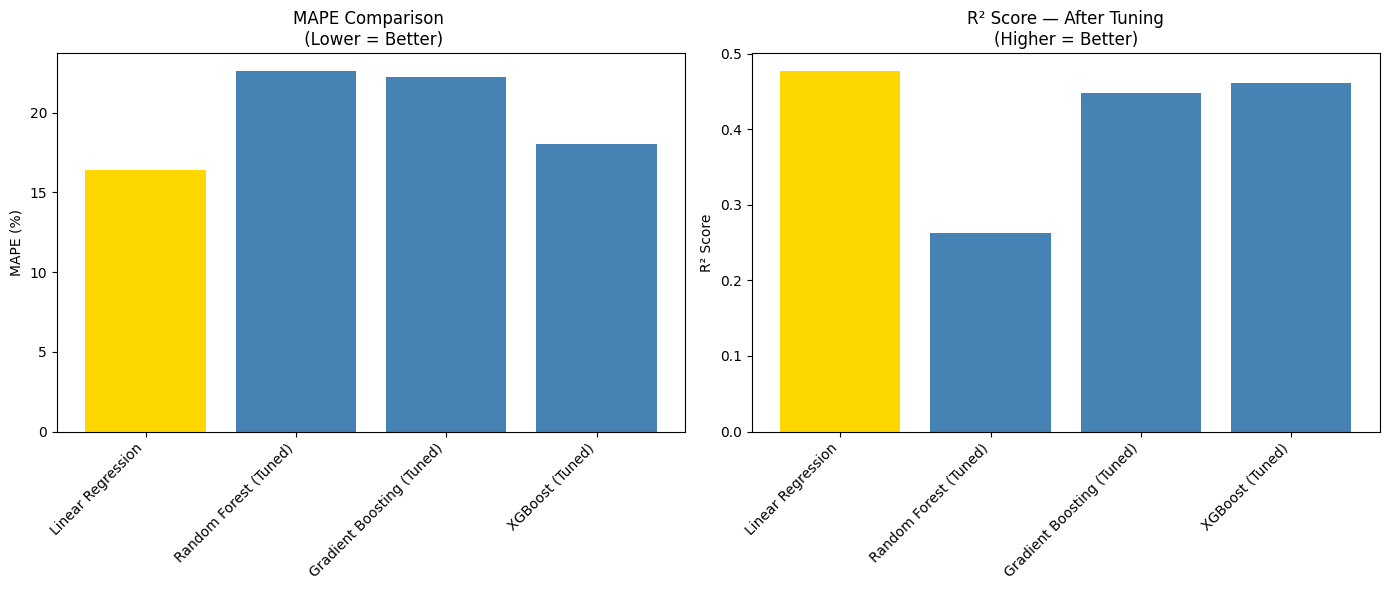

In [ ]:
import os

fig, axes = plt.subplots(1, 2, figsize=(14,6))

colors = ['gold' if m==best_name else 'steelblue' for m in models_names]

axes[0].bar(range(len(models_names)), mapes, color=colors)
axes[0].set_xticks(range(len(models_names)))
axes[0].set_xticklabels(models_names, rotation=45, ha='right')
axes[0].set_title('MAPE Comparison \n (Lower = Better)', fontsize=12)
axes[0].set_ylabel('MAPE (%)')

axes[1].bar(range(len(models_names)), r2s, color=colors)
axes[1].set_xticks(range(len(models_names)))
axes[1].set_xticklabels(models_names, rotation=45, ha='right')
axes[1].set_title('R² Score — After Tuning\n(Higher = Better)', fontsize=12)
axes[1].set_ylabel('R² Score')

plt.tight_layout()

output_dir = 'notebooks'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

plt.savefig(os.path.join(output_dir, '14_final_comparison.png'), dpi=150)
plt.show()

In [ ]:
import os
os.makedirs('models', exist_ok=True)

with open('models/best_model.pkl', 'wb') as f:
  pickle.dump(best_model, f)

model_info = {
    'best_model_name': best_name,
    'best_mape': round(best_mape, 2),
    'selected_features': available
}

with open('models/model_info.json', 'w') as f:
  json.dump(model_info, f, indent=4)

